# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv('../data/am_pm.csv')

In [3]:
X = df[['am', 'pm']]
y = df['target']

model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


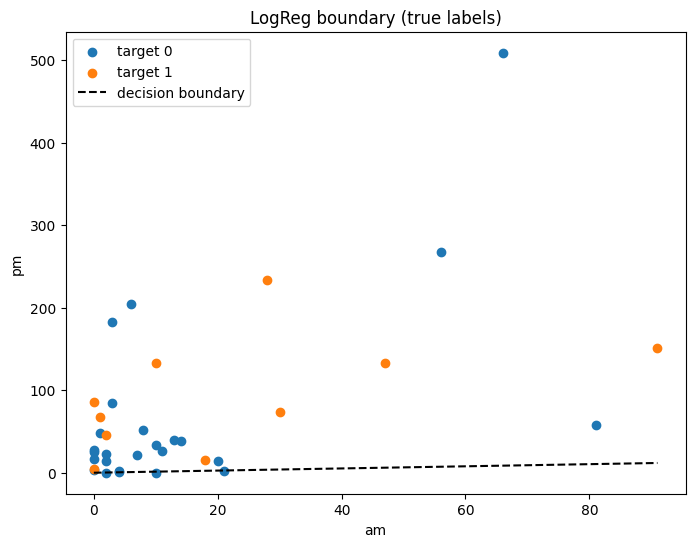

In [4]:
# plotting + decision boundary
plt.figure(figsize=(8,6))

for t in [0, 1]:
    subset = df[df['target'] == t]
    plt.scatter(subset['am'], subset['pm'], label=f'target {t}')

# decision boundary
w1, w2 = model.coef_[0]
x_vals = np.linspace(df['am'].min(), df['am'].max(), 100)
y_vals = -(w1 / w2) * x_vals

plt.plot(x_vals, y_vals, 'k--', label='decision boundary')

plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.title('LogReg boundary (true labels)')
plt.show()

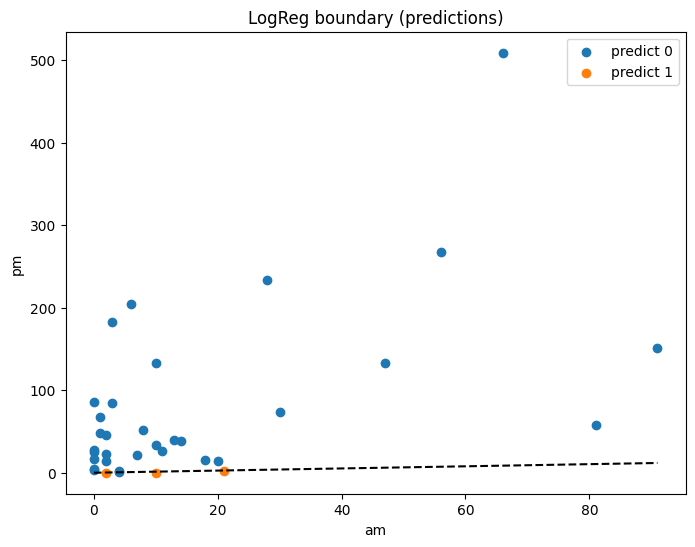

In [5]:
# plotting with predictions
df['predict'] = model.predict(X)

plt.figure(figsize=(8,6))

for t in [0, 1]:
    subset = df[df['predict'] == t]
    plt.scatter(subset['am'], subset['pm'], label=f'predict {t}')

plt.plot(x_vals, y_vals, 'k--')

plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.title('LogReg boundary (predictions)')
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [6]:
# standardizing features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['am', 'pm']])

In [7]:
# training model (again)
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X_scaled, df['target'])

df['predict_scaled'] = model.predict(X_scaled)

In [8]:
accuracy_scaled = accuracy_score(df['target'], df['predict_scaled'])
print("Scaled accuracy:", accuracy_scaled)

Scaled accuracy: 0.7428571428571429


In [9]:
most_common = df['target'].mode()[0]

df['naive'] = most_common

accuracy_naive = accuracy_score(df['target'], df['naive'])
print("Naive accuracy:", accuracy_naive)

Naive accuracy: 0.7142857142857143


- Answering the question: Prediction model got better by 3% that naive one.

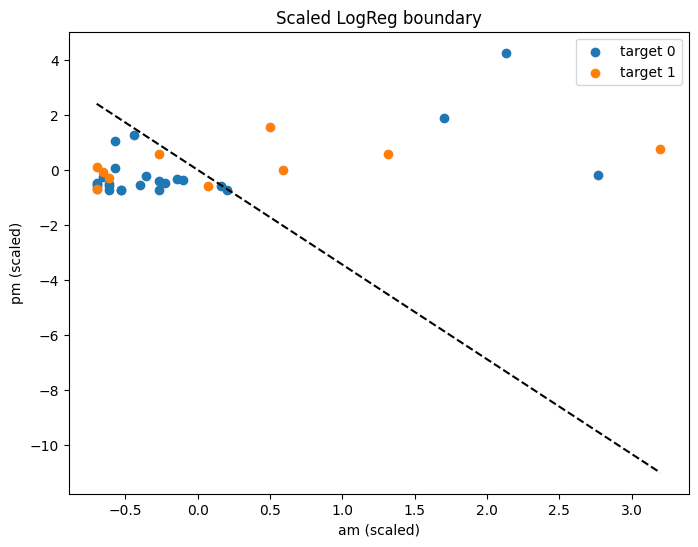

In [10]:
w1, w2 = model.coef_[0]

x_vals = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y_vals = -(w1 / w2) * x_vals

plt.figure(figsize=(8,6))

for t in [0,1]:
    subset = X_scaled[df['target'] == t]
    plt.scatter(subset[:,0], subset[:,1], label=f'target {t}')

plt.plot(x_vals, y_vals, 'k--')
plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.legend()
plt.title('Scaled LogReg boundary')
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [11]:
svm = SVC(probability=True, random_state=21)
svm.fit(X_scaled, df['target'])

df['predict_svm'] = svm.predict(X_scaled)

In [12]:
# measuring accuracy
accuracy_svm = accuracy_score(df['target'], df['predict_svm'])
print("SVM accuracy:", accuracy_svm)

SVM accuracy: 0.7428571428571429


In [13]:
for kernel in ['linear', 'rbf', 'poly']:
    model = SVC(kernel=kernel, probability=True, random_state=21)
    model.fit(X_scaled, df['target'])
    pred = model.predict(X_scaled)
    acc = accuracy_score(df['target'], pred)
    print(kernel, acc)

linear 0.7142857142857143
rbf 0.7428571428571429
poly 0.7428571428571429


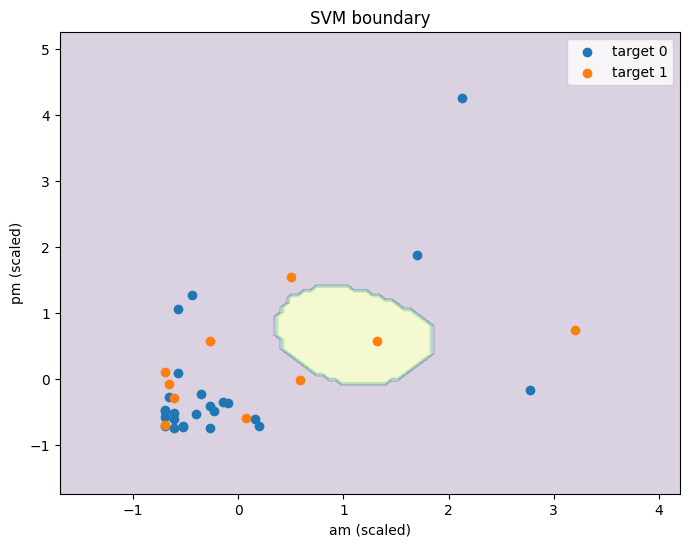

In [14]:
# mesh grid
x_min, x_max = X_scaled[:,0].min()-1, X_scaled[:,0].max()+1
y_min, y_max = X_scaled[:,1].min()-1, X_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.2)

# points
for t in [0,1]:
    subset = X_scaled[df['target']==t]
    plt.scatter(subset[:,0], subset[:,1], label=f'target {t}')

plt.xlabel('am (scaled)')
plt.ylabel('pm (scaled)')
plt.legend()
plt.title('SVM boundary')
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [15]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_scaled, df['target'])

df['predict_tree'] = tree.predict(X_scaled)

In [16]:
accuracy_tree = accuracy_score(df['target'], df['predict_tree'])
print("Tree accuracy:", accuracy_tree)

Tree accuracy: 0.9428571428571428


In [17]:
for d in [1,2,3,4,5]:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_scaled, df['target'])
    pred = model.predict(X_scaled)
    acc = accuracy_score(df['target'], pred)
    print(d, acc)

1 0.7714285714285715
2 0.8571428571428571
3 0.8857142857142857
4 0.9428571428571428
5 0.9714285714285714


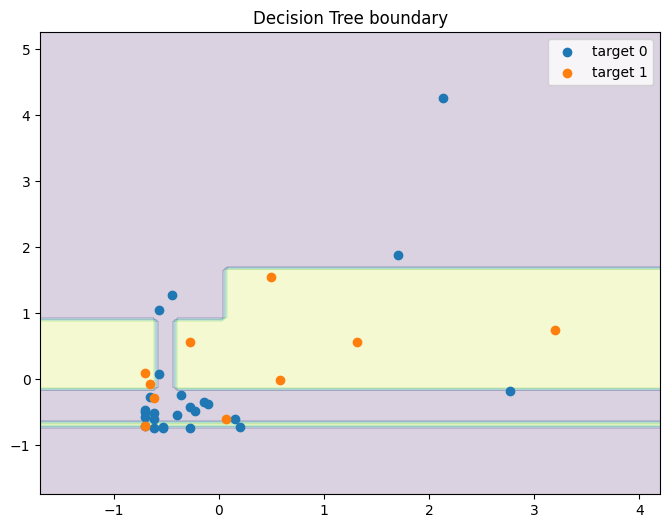

In [18]:
x_min, x_max = X_scaled[:,0].min()-1, X_scaled[:,0].max()+1
y_min, y_max = X_scaled[:,1].min()-1, X_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.2)

for t in [0,1]:
    subset = X_scaled[df['target']==t]
    plt.scatter(subset[:,0], subset[:,1], label=f'target {t}')

plt.legend()
plt.title('Decision Tree boundary')
plt.show()

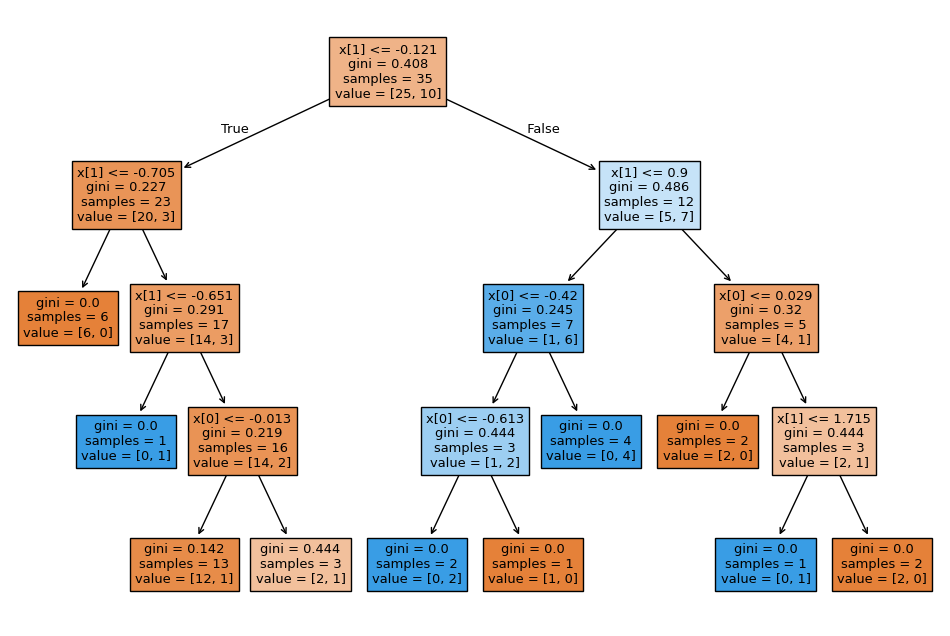

In [19]:
plt.figure(figsize=(12,8))
plot_tree(tree, filled=True)
plt.show()

- Answering the question: 4 leaves